In [1]:
import numpy as np
import pandas as pd 
from pathlib import Path
import glob

import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

In [9]:
# Load predictions

cp = '38_mm4_transductif_reg-2025-12-09_11-14'

output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')
pred_path = output_path / cp / 'predictions-biomass.csv'
predictions = pd.read_csv(pred_path, index_col='survey_id')
predictions = np.exp(predictions) - 1

# Load R2 scores
td_r2 = pd.read_csv(next((output_path / cp).glob("testR2*.csv")), index_col = 0)
rf_r2 = pd.read_csv( Path('/data/data/malpolon/xgb') / 'rf-bm-test.csv', index_col = 0)
rf2_r2 = pd.read_csv( Path('/data/data/malpolon/xgb') / 'rf2-bm-test.csv', index_col = 0)

In [4]:
# Load targets

p = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/database_common.csv')
df = pd.read_csv(p, index_col='survey_id', usecols = ['survey_id', 'subset'] + list(predictions.columns))
targets = df.loc[df['subset'] == 'test', predictions.columns]

## Display R2

In [12]:
scores = pd.concat([rf_r2["pearsonr"], rf2_r2["pearsonr"], td_r2["pearsonr"]], axis = 1)
names = ['RF+val', 'RF', 'Transductive']
scores.columns = names

In [13]:
y = []

for n in names:
    y1 = scores[[n]].sort_values(ascending=False, by=n)
    y1.reset_index(inplace=True)
    y1.columns = ['species', 'pearsonr']
    y1['x'] = np.arange(len(y1))
    y1['model'] = n
    y.append(y1)

data = pd.concat(y)

In [14]:
import plotly.express as px

fig = px.line(data[data['x'] <= 400], x='x', y='pearsonr', color='model', template = 'simple_white',
           width = 800, height=800,
           color_discrete_sequence = px.colors.qualitative.Pastel)

fig.update_layout(
    xaxis_title='Species rank',
    yaxis_title='Pearson score',
    font=dict(size=20),
    legend_title_text='',
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)

fig.update_traces(line={'width': 4})

## Display best species predictions

<Axes: xlabel='Notolabrus parilus', ylabel='Notolabrus parilus'>

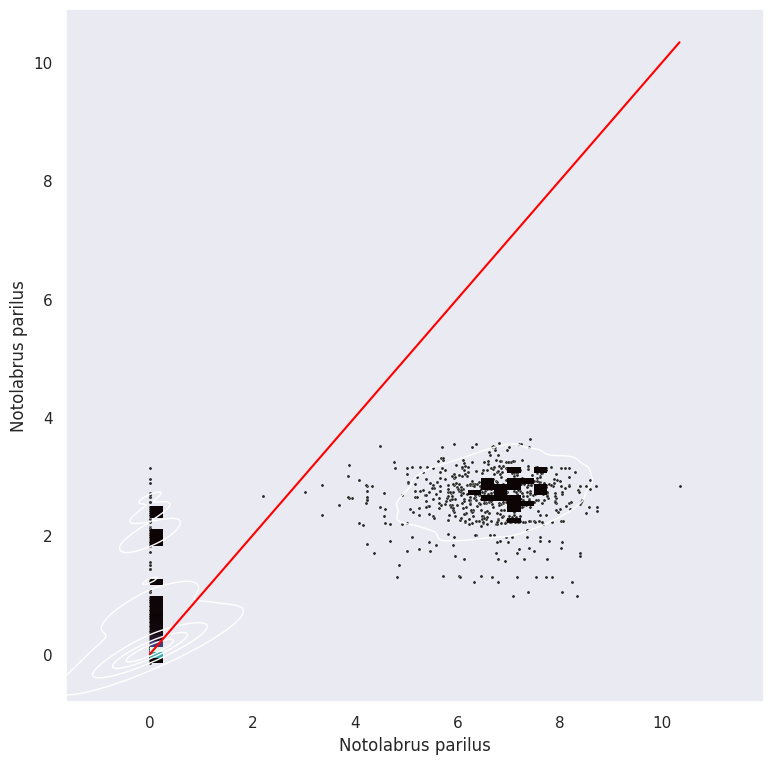

In [8]:
s = 'Notolabrus parilus'

x, y = np.log(1+targets[s]), np.log(1+predictions[s])

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')

## Species richness

<Axes: xlabel='None', ylabel='None'>

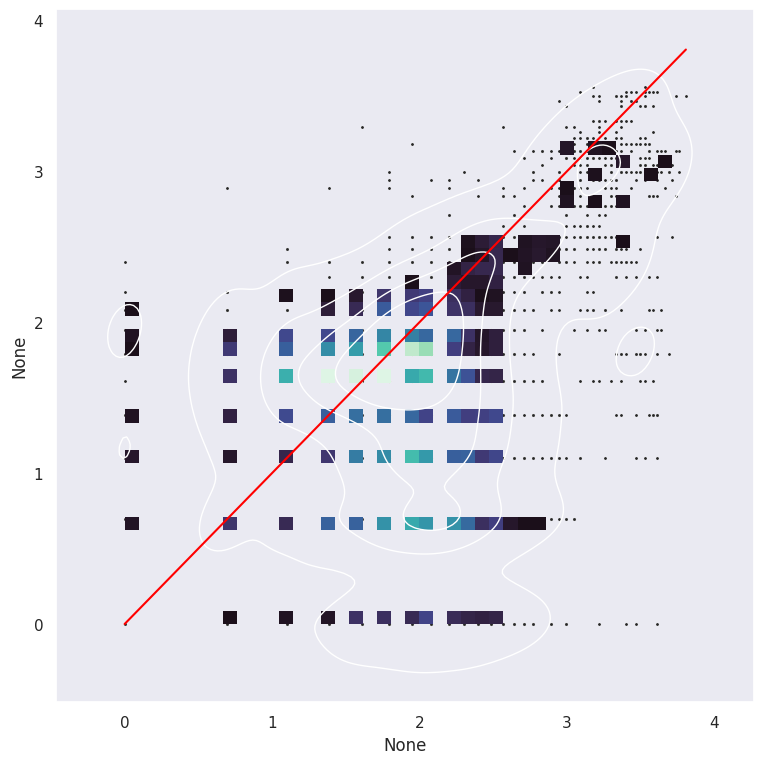

In [9]:
x, y = np.log(1+targets_sr), np.log(1+predictions_sr)

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')